### Подготовим данные под работу с нашей задачей

В качестве задачи для будущей нейронной сети - мы будем определять кузов автомобиля. Нам нужно решить с тем, какие типы кузова мы можем взять

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
df = pd.read_csv('../data/df_images.csv')
df

,kolesa_id,brand,body_type,img_filename
0,220599328,Chevrolet,Седан,220599328.webp
1,222486528,Chevrolet,Седан,222486528.webp
2,218695550,Chevrolet,Внедорожник,218695550.webp
3,220471159,Chevrolet,Хэтчбек,220471159.webp
4,214781208,Chevrolet,Седан,214781208.webp
...,...,...,...,...
4959,222478046,Hyundai,Седан,222478046.webp
4960,222704181,Hyundai,Седан,222704181.webp
4961,220000872,Hyundai,Седан,220000872.webp
4962,222542135,Hyundai,Седан,222542135.webp


Сразу отметим, что при сборе данных оказывалось что не все в объявлении первым/главным фото делали общий вид авто, кто-то фотографировал салон, кто-то отдельно фару, колесо, шилдик. Также из-за того, что фото при загрузке все скачивались в разрешении 750 × 470 - то на тех фото, по всей видимости, снятых на телефон вертикально, не видно почти всей машины, а часто видна часть крыши и небо. Все такие фото просматривались вручную и отметались. Возможно, не все фото остались идеальные + автоматизировать это в рамках проекта не вышло бы и проще было отсмотреть вручную.

In [17]:
df.isna().sum()

kolesa_id       0
brand           0
body_type       0
img_filename    0
dtype: int64

Пропусков нет

In [18]:
df['body_type'].value_counts()

body_type
Седан           2789
Кроссовер       1157
Внедорожник      487
Хэтчбек          148
Минивэн          118
Универсал        112
Лифтбек           36
Купе              32
Фургон            32
Пикап             15
Микроавтобус      15
Микровэн          13
Кабриолет          6
Родстер            4
Name: count, dtype: int64

У нас больше всего седанов и достаточно кроссоверов и внедорожников. По остальным классам - авто довольно мало и логичнее решать задачу бинарной классификации, где определять является ли авто седанов или SUV (кроссоверы + внедорожники). Закодируем их как 0 и 1 соответственно

In [19]:
df = df[df['body_type'].isin(['Седан', 'Кроссовер', 'Внедорожник'])]
df['target'] = 1
df.loc[df['body_type'] == 'Седан', 'target'] = 0
df['target'].value_counts()

target
0    2789
1    1644
Name: count, dtype: int64

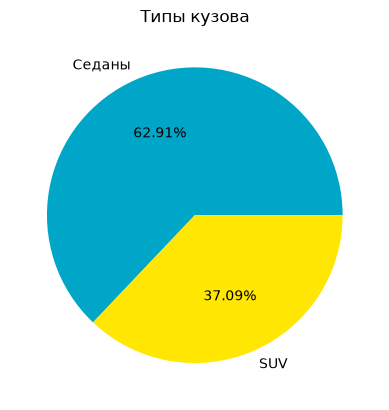

In [20]:
plt.figsize=(8, 6)

plt.title('Типы кузова')
plt.pie(df['target'].value_counts(), labels=['Седаны', 'SUV'], colors=['#00A6C8', '#FFE703'], autopct='%1.2f%%') # https://stackoverflow.com/questions/21572870/percent-label-position-in-pie-chart

plt.show()

Не идеальный баланс, но в целом терпимый. Оставляем как есть

Также т.к. мы основываемся на задаче на основе типа кузова, то уберем столбец с маркой. ID объявления и не закодированное название классов оставим.

In [21]:
df_brand = df.drop(columns='target')

# https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_brand['target'] = le.fit_transform(df['brand'])

df_brand.to_csv('../data/brand_df_images.csv', index=False)
df_brand

,kolesa_id,brand,body_type,img_filename,target
0,220599328,Chevrolet,Седан,220599328.webp,2
1,222486528,Chevrolet,Седан,222486528.webp,2
2,218695550,Chevrolet,Внедорожник,218695550.webp,2
4,214781208,Chevrolet,Седан,214781208.webp,2
5,222346737,Chevrolet,Седан,222346737.webp,2
...,...,...,...,...,...
4959,222478046,Hyundai,Седан,222478046.webp,3
4960,222704181,Hyundai,Седан,222704181.webp,3
4961,220000872,Hyundai,Седан,220000872.webp,3
4962,222542135,Hyundai,Седан,222542135.webp,3


In [22]:
df = df.drop(columns=['brand'])
df

,kolesa_id,body_type,img_filename,target
0,220599328,Седан,220599328.webp,0
1,222486528,Седан,222486528.webp,0
2,218695550,Внедорожник,218695550.webp,1
4,214781208,Седан,214781208.webp,0
5,222346737,Седан,222346737.webp,0
...,...,...,...,...
4959,222478046,Седан,222478046.webp,0
4960,222704181,Седан,222704181.webp,0
4961,220000872,Седан,220000872.webp,0
4962,222542135,Седан,222542135.webp,0


Выведем несколько фото-примеров.

Toyota


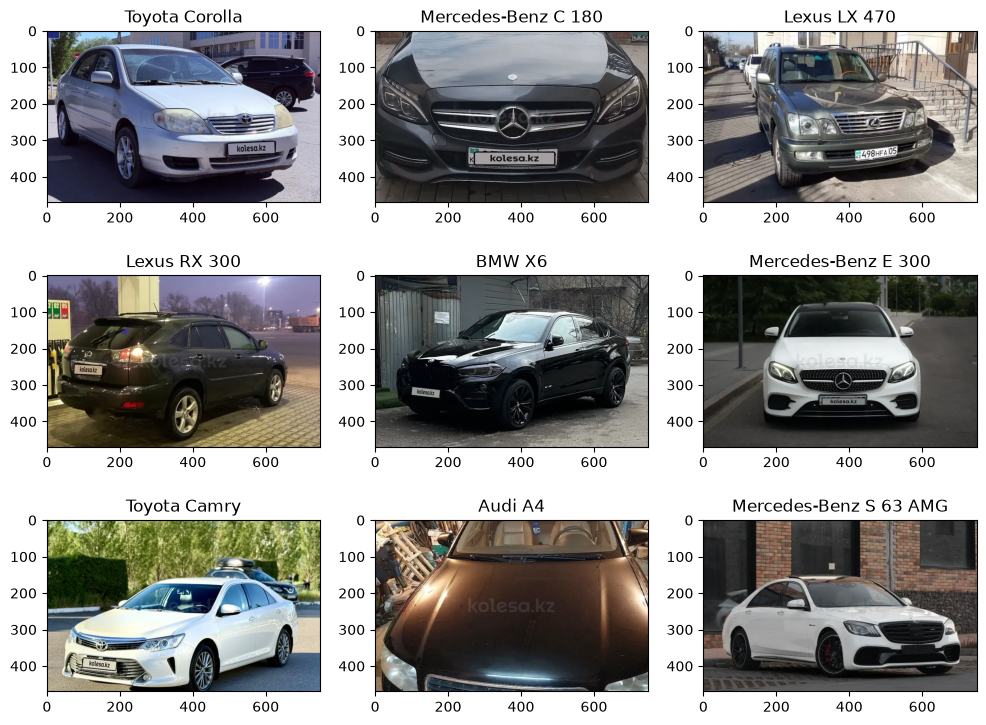

In [43]:
sample_images_path = os.listdir('../data/sample_images')

# https://stackoverflow.com/questions/35286540/how-to-display-an-image
import matplotlib.image as mpimg

clean_df = pd.read_csv('../data/clean_df.csv')
print(clean_df.loc[clean_df['img_filename'] == '222102985.webp', 'brand'].iloc[0])

plt.figure(figsize = (12, 9))
for path in sample_images_path:
    plt.subplot(3, 3, sample_images_path.index(path) + 1)
    car_name = clean_df.loc[clean_df['img_filename'] == path, 'brand'].iloc[0] + ' ' + clean_df.loc[clean_df['img_filename'] == path, 'model'].iloc[0]
    plt.title(car_name)
    img = mpimg.imread(f'../data/sample_images/{path}')
    imgplot = plt.imshow(img)

plt.show()

Можно увидеть, что ракурсы, фон и качество фото разные. А это всего 9 "рандомных" фото

In [ ]:
df.to_csv('../data/prepared_df_images.csv', index=False)